# Week 6 Feature Engineering and Market Metrics

**IDX Exchange Data Analyst Internship**<br>
**Analysis period:** January 2024 through June 2026

This report documents the market features added to the cleaned California
Residential datasets, the California Department of Education school-district
assignment, and the resulting market and competitive segments.

### Report Guide

1. **Engineered Market Fields** defines every metric and its exact formula.
2. **Populated Sample** shows those fields on real sold records.
3. **School-District Enrichment** explains the geographic assignment.
4. **Market Segmentation Fields** defines every field used to group results.
5. **Segment Results** compares property, geography, and office groups.
6. **Validation** confirms row preservation and identifies Week 7 review items.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display


ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

FEATURE_DIR = ROOT / "data" / "features"

COLORS = {
    "ink": "#1F2937",
    "teal": "#0F766E",
    "blue": "#1F6B8C",
    "amber": "#D97706",
    "red": "#B91C1C",
    "green": "#15803D",
    "gray": "#6B7280",
}

pd.set_option("display.max_columns", 30)

In [2]:
validation = pd.read_csv(FEATURE_DIR / "week6_validation_summary.csv")
sample = pd.read_csv(FEATURE_DIR / "week6_feature_sample.csv")
county = pd.read_csv(FEATURE_DIR / "week6_county_summary.csv")
mls_area = pd.read_csv(FEATURE_DIR / "week6_mls_area_summary.csv")
property_type = pd.read_csv(FEATURE_DIR / "week6_property_type_summary.csv")
subtype = pd.read_csv(FEATURE_DIR / "week6_property_subtype_summary.csv")
offices = pd.read_csv(FEATURE_DIR / "week6_office_summary.csv")
districts = pd.read_csv(FEATURE_DIR / "week6_school_district_summary.csv")

required_reports = {
    "validation": validation,
    "sample": sample,
    "county": county,
    "MLS area": mls_area,
    "property type": property_type,
    "property subtype": subtype,
    "offices": offices,
    "school districts": districts,
}
assert all(not report.empty for report in required_reports.values())


def validation_value(dataset, field):
    match = validation[validation["dataset"].eq(dataset)]
    if match.empty:
        raise KeyError(f"Missing validation row: {dataset}")
    return match.iloc[0][field]


print("Week 6 report inputs loaded successfully.")

Week 6 report inputs loaded successfully.


## Completion Snapshot

In [3]:
sold_rows = int(validation_value("sold_residential", "output_rows"))
ratio_rows = int(
    validation_value("sold_residential", "price_ratio_populated")
)
ppsf_rows = int(
    validation_value("sold_residential", "price_per_sq_ft_populated")
)
district_rows = int(
    validation_value("sold_residential", "any_cde_district_populated")
)

snapshot_html = f'''
<div style="display:grid;grid-template-columns:repeat(4,1fr);gap:14px;margin:8px 0 18px 0;">
  <div style="border-top:5px solid {COLORS["teal"]};padding:16px;background:#F7FAFA;">
    <div style="color:{COLORS["gray"]};font-size:13px;">Feature-Ready Sold Rows</div>
    <div style="color:{COLORS["ink"]};font-size:28px;font-weight:700;">{sold_rows:,}</div>
  </div>
  <div style="border-top:5px solid {COLORS["blue"]};padding:16px;background:#F7F9FB;">
    <div style="color:{COLORS["gray"]};font-size:13px;">Price Ratios Populated</div>
    <div style="color:{COLORS["ink"]};font-size:28px;font-weight:700;">{ratio_rows:,}</div>
  </div>
  <div style="border-top:5px solid {COLORS["amber"]};padding:16px;background:#FFFBF3;">
    <div style="color:{COLORS["gray"]};font-size:13px;">PPSF Values Populated</div>
    <div style="color:{COLORS["ink"]};font-size:28px;font-weight:700;">{ppsf_rows:,}</div>
  </div>
  <div style="border-top:5px solid {COLORS["green"]};padding:16px;background:#F5FAF6;">
    <div style="color:{COLORS["gray"]};font-size:13px;">CDE District Matches</div>
    <div style="color:{COLORS["ink"]};font-size:28px;font-weight:700;">{district_rows:,}</div>
  </div>
</div>
'''
display(HTML(snapshot_html))

## Engineered Market Fields: Quick Reference

Ratios are stored as decimals so Tableau can format them as percentages.
Invalid or missing denominators remain blank. Negative date intervals are
retained and counted for later data-quality review rather than silently
deleted.

**Important:** `PriceRatio` and `CloseToOriginalListRatio` use the same formula
because that is how both fields are defined in the internship handbook. They
are stored as separate columns for their different dashboard labels, but their
values are currently identical.

In [4]:
metric_definitions = pd.DataFrame(
    [
        {
            "Metric": "Price Ratio",
            "Saved Column": "PriceRatio",
            "Exact Calculation": "ClosePrice / OriginalListPrice",
            "What It Tells Us": "Measures negotiation strength",
            "Sold Rows Populated": validation_value(
                "sold_residential", "price_ratio_populated"
            ),
        },
        {
            "Metric": "Price Per Sq Ft",
            "Saved Column": "PricePerSqFt",
            "Exact Calculation": "ClosePrice / LivingArea",
            "What It Tells Us": "Normalizes price across property sizes",
            "Sold Rows Populated": validation_value(
                "sold_residential", "price_per_sq_ft_populated"
            ),
        },
        {
            "Metric": "Days on Market",
            "Saved Column": "DaysOnMarket",
            "Exact Calculation": "DaysOnMarket (raw MLS field)",
            "What It Tells Us": "Time-to-sell indicator",
            "Sold Rows Populated": sold_rows,
        },
        {
            "Metric": "Year / Month / YrMo",
            "Saved Column": "Year, Month, YrMo",
            "Exact Calculation": "Derived from CloseDate",
            "What It Tells Us": "Enables time-series analysis",
            "Sold Rows Populated": validation_value(
                "sold_residential", "yrmo_populated"
            ),
        },
        {
            "Metric": "Close to Original List Ratio",
            "Saved Column": "CloseToOriginalListRatio",
            "Exact Calculation": "ClosePrice / OriginalListPrice",
            "What It Tells Us": "Captures full price-reduction history",
            "Sold Rows Populated": validation_value(
                "sold_residential", "price_ratio_populated"
            ),
        },
        {
            "Metric": "Listing to Contract Days",
            "Saved Column": "ListingToContractDays",
            "Exact Calculation": (
                "PurchaseContractDate - ListingContractDate"
            ),
            "What It Tells Us": (
                "Measures time from listing to accepted offer"
            ),
            "Sold Rows Populated": validation_value(
                "sold_residential",
                "listing_to_contract_days_populated",
            ),
        },
        {
            "Metric": "Contract to Close Days",
            "Saved Column": "ContractToCloseDays",
            "Exact Calculation": "CloseDate - PurchaseContractDate",
            "What It Tells Us": "Escrow and closing period duration",
            "Sold Rows Populated": validation_value(
                "sold_residential",
                "contract_to_close_days_populated",
            ),
        },
    ]
)

display(
    metric_definitions.style
    .hide(axis="index")
    .format({"Sold Rows Populated": "{:,.0f}"})
)

Metric,Saved Column,Exact Calculation,What It Tells Us,Sold Rows Populated
Price Ratio,PriceRatio,ClosePrice / OriginalListPrice,Measures negotiation strength,"447,025"
Price Per Sq Ft,PricePerSqFt,ClosePrice / LivingArea,Normalizes price across property sizes,"447,431"
Days on Market,DaysOnMarket,DaysOnMarket (raw MLS field),Time-to-sell indicator,"447,850"
Year / Month / YrMo,"Year, Month, YrMo",Derived from CloseDate,Enables time-series analysis,"447,850"
Close to Original List Ratio,CloseToOriginalListRatio,ClosePrice / OriginalListPrice,Captures full price-reduction history,"447,025"
Listing to Contract Days,ListingToContractDays,PurchaseContractDate - ListingContractDate,Measures time from listing to accepted offer,"447,652"
Contract to Close Days,ContractToCloseDays,CloseDate - PurchaseContractDate,Escrow and closing period duration,"447,653"


### How to Read the Ratios

- **1.00** means the property closed at its original list price.
- **Above 1.00** means the property closed above its original list price.
- **Below 1.00** means the property closed below its original list price.

For example, a ratio of **0.97** means the closing price was 97% of the
original list price. A ratio of **1.03** means it closed 3% above the original
list price.

### Populated Sample

In [5]:
sample_columns = [
    "ListingId",
    "CountyOrParish",
    "PropertySubType",
    "ClosePrice",
    "PriceRatio",
    "PricePerSqFt",
    "DaysOnMarket",
    "YrMo",
    "ListingToContractDays",
    "ContractToCloseDays",
    "CDEElementarySchoolDistrict",
    "CDEHighSchoolDistrict",
    "CDEUnifiedSchoolDistrict",
]
sample_display = sample[sample_columns].head(12)

display(
    sample_display.style
    .hide(axis="index")
    .format(
        {
            "ClosePrice": "${:,.0f}",
            "PriceRatio": "{:.3f}",
            "PricePerSqFt": "${:,.2f}",
            "DaysOnMarket": "{:,.0f}",
            "ListingToContractDays": "{:,.0f}",
            "ContractToCloseDays": "{:,.0f}",
        },
        na_rep="",
    )
)

ListingId,CountyOrParish,PropertySubType,ClosePrice,PriceRatio,PricePerSqFt,DaysOnMarket,YrMo,ListingToContractDays,ContractToCloseDays,CDEElementarySchoolDistrict,CDEHighSchoolDistrict,CDEUnifiedSchoolDistrict
219132708PS,Riverside,Condominium,"$269,000",0.769,$221.95,293,2026-06,353,54,,,Palm Springs Unified
219135362DA,Riverside,SingleFamilyResidence,"$3,050,000",0.763,$735.65,258,2026-06,259,29,,,Palm Springs Unified
219136211DA,Riverside,SingleFamilyResidence,"$1,498,000",0.902,$495.37,259,2026-06,259,13,,,Coachella Valley Unified
219137129DA,Riverside,SingleFamilyResidence,"$950,000",0.679,$301.01,223,2026-06,239,33,,,Desert Sands Unified
219137628DA,Riverside,SingleFamilyResidence,"$1,095,000",0.916,$404.96,152,2026-06,198,50,,,Palm Springs Unified
219138188DA,Riverside,Condominium,"$239,000",0.976,$284.52,194,2026-06,227,14,,,Desert Sands Unified
219140046DA,Riverside,Condominium,"$270,000",0.831,$252.81,178,2026-06,178,19,,,Palm Springs Unified
219141799DA,Riverside,SingleFamilyResidence,"$1,929,500",0.908,$503.92,156,2026-06,156,4,,,Coachella Valley Unified
219142122DA,Riverside,SingleFamilyResidence,"$960,000",0.817,$325.42,142,2026-06,142,13,,,Palm Springs Unified
219142675DA,Riverside,SingleFamilyResidence,"$1,200,000",0.857,$410.96,115,2026-06,"1,837",31,,,Hemet Unified


## School-District Enrichment

The 2024-25 California Department of Education layer contains 937 polygons:
516 elementary, 76 high, and 345 unified districts. District types are stored
in separate CDE-prefixed columns because elementary and high service areas
overlap by design. The original MLS `HighSchoolDistrict` field remains
unchanged.

In [6]:
district_quality = pd.DataFrame(
    [
        {
            "Dataset": "Residential Listings",
            "Total Rows": validation_value(
                "listings_residential", "output_rows"
            ),
            "Coordinate Coverage": (
                validation_value(
                    "listings_residential", "valid_coordinate_rows"
                )
                / validation_value("listings_residential", "output_rows")
            ),
            "District Match Rate": (
                validation_value(
                    "listings_residential",
                    "any_cde_district_populated",
                )
                / validation_value(
                    "listings_residential", "valid_coordinate_rows"
                )
            ),
            "Coordinates Without Match": validation_value(
                "listings_residential", "valid_coordinate_rows"
            )
            - validation_value(
                "listings_residential",
                "any_cde_district_populated",
            ),
        },
        {
            "Dataset": "Residential Sold",
            "Total Rows": validation_value(
                "sold_residential", "output_rows"
            ),
            "Coordinate Coverage": (
                validation_value(
                    "sold_residential", "valid_coordinate_rows"
                )
                / validation_value("sold_residential", "output_rows")
            ),
            "District Match Rate": (
                validation_value(
                    "sold_residential", "any_cde_district_populated"
                )
                / validation_value(
                    "sold_residential", "valid_coordinate_rows"
                )
            ),
            "Coordinates Without Match": validation_value(
                "sold_residential", "valid_coordinate_rows"
            )
            - validation_value(
                "sold_residential",
                "any_cde_district_populated",
            ),
        },
    ]
)

display(HTML("<h3>School-district match coverage</h3>"))
display(
    district_quality.style
    .hide(axis="index")
    .format(
        {
            "Total Rows": "{:,.0f}",
            "Coordinate Coverage": "{:.2%}",
            "District Match Rate": "{:.2%}",
            "Coordinates Without Match": "{:,.0f}",
        }
    )
)

Dataset,Total Rows,Coordinate Coverage,District Match Rate,Coordinates Without Match
Residential Listings,"615,671",86.85%,99.97%,157
Residential Sold,"447,850",99.02%,99.97%,117


### District Boundary Overlap Review

- **Separate Elementary + High districts** is a normal structure: one district
  serves elementary grades and another serves high-school grades.
- **Elementary + Unified boundary overlap** is less common and is retained as a
  review flag. It does not create duplicate property rows.

In [7]:
district_overlap = pd.DataFrame(
    [
        {
            "Dataset": "Residential Listings",
            "Separate Elementary + High Districts": validation_value(
                "listings_residential",
                "cde_elementary_and_high_overlap",
            ),
            "Elementary + Unified Boundary Review": validation_value(
                "listings_residential",
                "cde_elementary_and_unified_overlap",
            ),
        },
        {
            "Dataset": "Residential Sold",
            "Separate Elementary + High Districts": validation_value(
                "sold_residential",
                "cde_elementary_and_high_overlap",
            ),
            "Elementary + Unified Boundary Review": validation_value(
                "sold_residential",
                "cde_elementary_and_unified_overlap",
            ),
        },
    ]
)

display(
    district_overlap.style
    .hide(axis="index")
    .format(
        {
            "Separate Elementary + High Districts": "{:,.0f}",
            "Elementary + Unified Boundary Review": "{:,.0f}",
        }
    )
)

Dataset,Separate Elementary + High Districts,Elementary + Unified Boundary Review
Residential Listings,"122,016","2,508"
Residential Sold,"107,591","1,812"


In [8]:
district_top = (
    districts.sort_values(
        ["DistrictType", "ClosedSales"],
        ascending=[True, False],
    )
    .groupby("DistrictType", group_keys=False)
    .head(5)
)

display(HTML("<h3>Five largest sold segments by district type</h3>"))
display(
    district_top[
        [
            "DistrictType",
            "SchoolDistrict",
            "ClosedSales",
            "MedianClosePrice",
            "MedianPricePerSqFt",
            "MedianDaysOnMarket",
            "MedianCloseToOriginalListRatio",
        ]
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "ClosedSales": "{:,.0f}",
            "MedianClosePrice": "${:,.0f}",
            "MedianPricePerSqFt": "${:,.2f}",
            "MedianDaysOnMarket": "{:,.0f}",
            "MedianCloseToOriginalListRatio": "{:.3f}",
        },
        na_rep="",
    )
)

DistrictType,SchoolDistrict,ClosedSales,MedianClosePrice,MedianPricePerSqFt,MedianDaysOnMarket,MedianCloseToOriginalListRatio
Elementary,Menifee Union,"4,135","$589,000",$289.78,24,0.994
Elementary,Chula Vista Elementary,"3,786","$810,000",$482.73,14,1.000
Elementary,Saugus Union,"2,837","$810,000",$424.00,23,0.993
Elementary,Escondido Union,"2,786","$824,700",$482.41,16,0.994
Elementary,La Mesa-Spring Valley,"2,327","$815,000",$534.31,13,1.000
High,Grossmont Union High,"7,765","$799,000",$511.92,13,1.000
High,Perris Union High,"6,678","$575,000",$288.18,24,0.999
High,Antelope Valley Union High,"6,599","$490,000",$276.60,25,1.000
High,Chaffey Joint Union High,"6,361","$705,000",$424.45,17,1.000
High,William S. Hart Union High,"6,271","$802,000",$433.70,22,0.992


## Market Segmentation Fields

These fields do not create new measurements. They divide the sold records into
groups so the same market metrics can be compared across property categories,
locations, and competing offices.

In [9]:
segment_definitions = pd.DataFrame(
    [
        {
            "Analysis Category": "Property",
            "Primary Field": "PropertyType",
            "Detailed Field": "PropertySubType",
            "What the Fields Identify": (
                "Broad property category and its more specific subtype"
            ),
            "Dashboard Use": (
                "Compare prices, market time, and sale-to-list performance "
                "across property categories"
            ),
        },
        {
            "Analysis Category": "Geography",
            "Primary Field": "CountyOrParish",
            "Detailed Field": "MLSAreaMajor",
            "What the Fields Identify": (
                "County-level market and the more detailed MLS market area"
            ),
            "Dashboard Use": (
                "Compare broader county trends with local-area performance"
            ),
        },
        {
            "Analysis Category": "Competitive Intelligence",
            "Primary Field": "ListOfficeName",
            "Detailed Field": "BuyerOfficeName",
            "What the Fields Identify": (
                "Office representing the seller and office representing "
                "the buyer"
            ),
            "Dashboard Use": (
                "Compare office transaction volume and performance on both "
                "sides of a sale"
            ),
        },
    ]
)

display(segment_definitions.style.hide(axis="index"))

Analysis Category,Primary Field,Detailed Field,What the Fields Identify,Dashboard Use
Property,PropertyType,PropertySubType,Broad property category and its more specific subtype,"Compare prices, market time, and sale-to-list performance across property categories"
Geography,CountyOrParish,MLSAreaMajor,County-level market and the more detailed MLS market area,Compare broader county trends with local-area performance
Competitive Intelligence,ListOfficeName,BuyerOfficeName,Office representing the seller and office representing the buyer,Compare office transaction volume and performance on both sides of a sale


## Segment Results

### Property: `PropertyType` and `PropertySubType`

`PropertyType` is the broad category. Because the approved analysis scope is
Residential only, it also confirms that non-residential records are excluded.
`PropertySubType` provides the useful detail, such as single-family residence,
condominium, or townhouse.

In [10]:
residential_sales = int(
    property_type.loc[
        property_type["PropertyType"].eq("Residential"),
        "ClosedSales",
    ].sum()
)
display(
    HTML(
        f'''
        <div style="border-left:5px solid {COLORS["teal"]};padding:12px 16px;background:#F7FAFA;margin:8px 0 18px 0;">
          <strong>PropertyType scope:</strong> Residential only
          <span style="color:{COLORS["gray"]};">({residential_sales:,} sold records)</span>
        </div>
        '''
    )
)

display(HTML("<h4>Largest PropertySubType segments</h4>"))
subtype_ranked = subtype[
    ~subtype["PropertySubType"].fillna("").str.strip().str.lower().isin(
        ["", "missing", "unknown", "n/a"]
    )
].head(12)
display(
    subtype_ranked.style
    .hide(axis="index")
    .format(
        {
            "ClosedSales": "{:,.0f}",
            "MedianClosePrice": "${:,.0f}",
            "MedianPricePerSqFt": "${:,.2f}",
            "MedianDaysOnMarket": "{:,.0f}",
            "MedianCloseToOriginalListRatio": "{:.3f}",
            "MedianListingToContractDays": "{:,.0f}",
            "MedianContractToCloseDays": "{:,.0f}",
        },
        na_rep="",
    )
)

PropertySubType,ClosedSales,MedianClosePrice,MedianPricePerSqFt,MedianDaysOnMarket,MedianCloseToOriginalListRatio,MedianListingToContractDays,MedianContractToCloseDays
SingleFamilyResidence,"335,503","$896,000",$533.27,17,1.000,23,29
Condominium,"73,562","$627,000",$564.13,24,0.986,30,28
Townhouse,"26,234","$800,000",$560.72,17,1.000,22,28
ManufacturedOnLand,"5,795","$320,000",$225.00,30,0.970,39,34
Duplex,"2,488","$910,000",$543.38,21,0.983,31,32
StockCooperative,"1,764","$360,000",$396.18,21,0.985,31,46
Cabin,507,"$241,000",$287.58,47,0.917,56,30
Triplex,379,"$1,135,000",$473.95,29,0.969,43,35
MixedUse,222,"$687,500",$433.95,52,0.926,67,32
Quadruplex,159,"$1,275,000",$376.95,34,0.948,44,36


### Geography: `CountyOrParish` and `MLSAreaMajor`

`CountyOrParish` supports broad regional comparisons. `MLSAreaMajor` provides
a more local market view within those larger regions.

In [11]:
county_top = county.head(12).copy()
display(HTML("<h4>Largest CountyOrParish sold segments</h4>"))
display(
    county_top.style
    .hide(axis="index")
    .format(
        {
            "ClosedSales": "{:,.0f}",
            "MedianClosePrice": "${:,.0f}",
            "MedianPricePerSqFt": "${:,.2f}",
            "MedianDaysOnMarket": "{:,.0f}",
            "MedianCloseToOriginalListRatio": "{:.3f}",
            "MedianListingToContractDays": "{:,.0f}",
            "MedianContractToCloseDays": "{:,.0f}",
        },
        na_rep="",
    )
)

CountyOrParish,ClosedSales,MedianClosePrice,MedianPricePerSqFt,MedianDaysOnMarket,MedianCloseToOriginalListRatio,MedianListingToContractDays,MedianContractToCloseDays
Los Angeles,"111,198","$905,000",$608.97,19,1.000,25,30
Riverside,"62,108","$600,000",$321.10,30,0.986,38,29
San Diego,"55,522","$900,000",$590.82,15,0.992,21,26
Orange,"50,386","$1,180,000",$674.10,14,0.994,25,29
San Bernardino,"41,575","$532,000",$332.00,24,0.992,32,32
Alameda,"21,204","$1,140,000",$700.87,14,1.020,14,23
Contra Costa,"20,461","$825,000",$521.90,14,1.000,15,23
Santa Clara,"19,647","$1,600,000",$965.91,10,1.022,10,24
Ventura,"14,019","$870,000",$516.83,28,0.990,35,24
San Mateo,"7,801","$1,700,000","$1,052.63",12,1.013,12,23


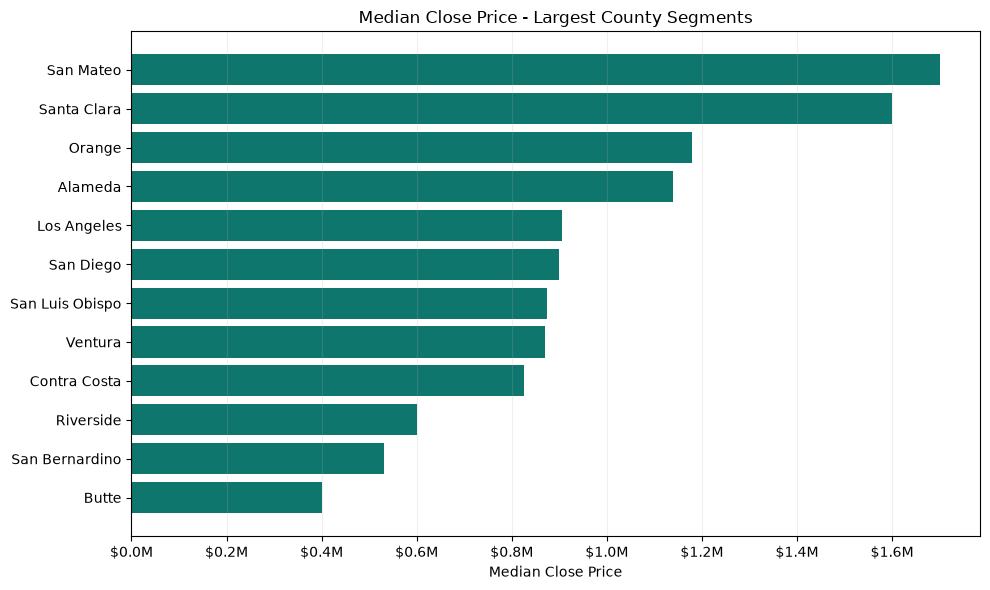

In [12]:
chart = county_top.sort_values("MedianClosePrice")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    chart["CountyOrParish"],
    chart["MedianClosePrice"],
    color=COLORS["teal"],
)
ax.set_title("Median Close Price - Largest County Segments")
ax.set_xlabel("Median Close Price")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"${value / 1_000_000:.1f}M")
)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
mls_area_labels = mls_area["MLSAreaMajor"].fillna("").str.strip()
undefined_area = (
    mls_area_labels.str.lower().isin(["", "missing", "unknown", "n/a"])
    | mls_area_labels.str.contains("not defined", case=False, na=False)
)
undefined_area_rows = int(mls_area.loc[undefined_area, "ClosedSales"].sum())
undefined_area_rate = undefined_area_rows / sold_rows
mls_area_ranked = mls_area.loc[~undefined_area].head(15)

display(
    HTML(
        f'''
        <div style="border-left:5px solid {COLORS["amber"]};padding:12px 16px;background:#FFFBF3;margin:8px 0 18px 0;">
          <strong>MLS-area quality note:</strong> {undefined_area_rows:,} sold records
          ({undefined_area_rate:.1%}) have a missing or undefined MLSAreaMajor.
          They remain in the dataset but are excluded from this ranking.
        </div>
        '''
    )
)
display(HTML("<h4>Largest defined MLSAreaMajor sold segments</h4>"))
display(
    mls_area_ranked.style
    .hide(axis="index")
    .format(
        {
            "ClosedSales": "{:,.0f}",
            "MedianClosePrice": "${:,.0f}",
            "MedianPricePerSqFt": "${:,.2f}",
            "MedianDaysOnMarket": "{:,.0f}",
            "MedianCloseToOriginalListRatio": "{:.3f}",
            "MedianListingToContractDays": "{:,.0f}",
            "MedianContractToCloseDays": "{:,.0f}",
        },
        na_rep="",
    )
)

MLSAreaMajor,ClosedSales,MedianClosePrice,MedianPricePerSqFt,MedianDaysOnMarket,MedianCloseToOriginalListRatio,MedianListingToContractDays,MedianContractToCloseDays
SRCAR - Southwest Riverside County,"21,870","$587,500",$293.76,23,0.997,32,31
252 - Riverside,"5,669","$657,500",$378.96,20,1.000,28,31
248 - Corona,"3,604","$758,693",$396.46,21,0.995,30,30
LAC - Lancaster,"3,322","$475,000",$270.62,25,1.000,30,34
VIC - Victorville,"3,159","$437,000",$238.70,24,1.000,32,34
263 - Banning/Beaumont/Cherry Valley,"3,156","$499,900",$259.97,30,0.992,37,34
274 - San Bernardino,"3,099","$500,000",$353.17,20,1.000,29,33
259 - Moreno Valley,"2,838","$555,000",$312.28,18,1.000,27,33
686 - Ontario,"2,818","$654,362",$416.88,20,1.000,26,32
264 - Fontana,"2,765","$650,000",$359.46,18,1.000,26,32


### Competitive Intelligence: `ListOfficeName` and `BuyerOfficeName`

`ListOfficeName` identifies the office representing the seller.
`BuyerOfficeName` identifies the office representing the buyer. Comparing both
fields shows which offices are most active and how their transactions perform
on each side of the market.

In [14]:
office_labels = offices["OfficeName"].fillna("").str.strip()
undefined_office = office_labels.str.lower().isin(
    ["", "missing", "unknown", "n/a"]
)
undefined_office_rows = int(
    offices.loc[undefined_office, "ClosedSales"].sum()
)
office_top = (
    offices.loc[~undefined_office]
    .sort_values(
        ["OfficeRole", "ClosedSales"],
        ascending=[True, False],
    )
    .groupby("OfficeRole", group_keys=False)
    .head(10)
)

display(
    HTML(
        f'''
        <div style="border-left:5px solid {COLORS["amber"]};padding:12px 16px;background:#FFFBF3;margin:8px 0 18px 0;">
          <strong>Office quality note:</strong> {undefined_office_rows:,}
          office-side records have a missing or unknown office name.
          They remain in the dataset but are excluded from this ranking.
        </div>
        '''
    )
)
display(HTML("<h4>Largest listing-side and buyer-side office segments</h4>"))
display(
    office_top[
        [
            "OfficeRole",
            "OfficeName",
            "ClosedSales",
            "MedianClosePrice",
            "MedianDaysOnMarket",
            "MedianCloseToOriginalListRatio",
        ]
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "ClosedSales": "{:,.0f}",
            "MedianClosePrice": "${:,.0f}",
            "MedianDaysOnMarket": "{:,.0f}",
            "MedianCloseToOriginalListRatio": "{:.3f}",
        },
        na_rep="",
    )
)

OfficeRole,OfficeName,ClosedSales,MedianClosePrice,MedianDaysOnMarket,MedianCloseToOriginalListRatio
Buyer Office,Compass,"29,612","$1,338,000",14,1.000
Buyer Office,Coldwell Banker Realty,"16,227","$1,199,000",16,0.996
Buyer Office,NONMEMBER MRML,"9,757","$502,000",26,0.986
Buyer Office,Keller Williams Realty,"6,900","$840,000",17,0.995
Buyer Office,Real Broker,"6,751","$801,000",17,0.999
Buyer Office,eXp Realty of California Inc,"5,702","$835,050",19,0.999
Buyer Office,First Team Real Estate,"5,670","$900,000",14,1.000
Buyer Office,"eXp Realty of California, Inc.","5,060","$730,000",18,1.000
Buyer Office,Berkshire Hathaway HomeServices California Properties,"4,517","$985,000",21,0.986
Buyer Office,Intero Real Estate Services,"3,880","$1,335,000",12,1.011


## Validation and Week 7 Carryover

No rows were removed during feature engineering. `PriceRatio` and
`CloseToOriginalListRatio` were verified as identical, as required by the
handbook formulas. Negative timeline intervals remain available for review.
Extreme price, PPSF, ratio, and days-on-market values remain unfiltered because
outlier treatment is the Week 7 task.

In [15]:
validation_display = validation[
    [
        "dataset",
        "input_rows",
        "output_rows",
        "rows_preserved",
        "price_ratio_columns_equal",
        "listing_to_contract_negative",
        "contract_to_close_negative",
    ]
].copy()
validation_display.columns = [
    "Dataset",
    "Input Rows",
    "Output Rows",
    "Rows Preserved",
    "Ratio Columns Equal",
    "Negative Listing-to-Contract",
    "Negative Contract-to-Close",
]

display(
    validation_display.style
    .hide(axis="index")
    .format(
        {
            "Input Rows": "{:,.0f}",
            "Output Rows": "{:,.0f}",
            "Negative Listing-to-Contract": "{:,.0f}",
            "Negative Contract-to-Close": "{:,.0f}",
        }
    )
)

Dataset,Input Rows,Output Rows,Rows Preserved,Ratio Columns Equal,Negative Listing-to-Contract,Negative Contract-to-Close
listings_residential,"615,671","615,671",True,True,301,268
sold_residential,"447,850","447,850",True,True,290,239


## Week 6 Outputs

- `listings_residential_features.csv`
- `sold_residential_market_features.csv`
- `week6_feature_sample.csv`
- `week6_county_summary.csv`
- `week6_mls_area_summary.csv`
- `week6_property_type_summary.csv`
- `week6_property_subtype_summary.csv`
- `week6_office_summary.csv`
- `week6_school_district_summary.csv`
- `week6_validation_summary.csv`

The feature-ready datasets are prepared for Week 7 outlier review and later
Tableau dashboard construction.

## Sources

- Cleaned CRMLS California Residential listing and sold datasets
- California Department of Education, California School District Areas
  2024-25